# Exploratory Data Analysis - Club Piscine MMM

This notebook performs exploratory analysis on the cleaned datasets to understand:
1. **Time series patterns** in quotes and media spend
2. **Correlations** between media channels and quote requests
3. **Seasonality** in the business
4. **Key insights** for building the MMM model

---

In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_palette('husl')

# Paths
project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path = project_root / 'reports' / 'figures'

# Create figures directory if it doesn't exist
figures_path.mkdir(parents=True, exist_ok=True)

print(f"Loading data from: {processed_path}")
print(f"Saving figures to: {figures_path}")

Loading data from: /Users/tuta/Desktop/busa693-clubpiscine/data/processed
Saving figures to: /Users/tuta/Desktop/busa693-clubpiscine/reports/figures


In [2]:
# Cell 2: Load Cleaned Datasets

# Load from CSV (more portable across pandas versions)
soumissions = pd.read_csv(processed_path / 'soumissions_quotes.csv')
budget = pd.read_csv(processed_path / 'budget_media_spend.csv')
tableau_medias = pd.read_csv(processed_path / 'tableau_medias_performance.csv')
calendrier = pd.read_csv(processed_path / 'calendrier_fiscal.csv')

# Convert date columns
tableau_medias['date_debut'] = pd.to_datetime(tableau_medias['date_debut'], errors='coerce')
tableau_medias['date_fin'] = pd.to_datetime(tableau_medias['date_fin'], errors='coerce')
calendrier['Date'] = pd.to_datetime(calendrier['Date'], errors='coerce')

print("Datasets loaded:")
print(f"  - Soumissions (Quotes): {soumissions.shape}")
print(f"  - Budget (Media Spend): {budget.shape}")
print(f"  - Tableau Medias: {tableau_medias.shape}")
print(f"  - Calendrier Fiscal: {calendrier.shape}")

# ============================================================
# FISCAL YEAR STRUCTURE EXPLANATION
# ============================================================
print("\n" + "=" * 70)
print("FISCAL YEAR STRUCTURE - IMPORTANT!")
print("=" * 70)
print("""
Club Piscine uses a fiscal year that runs from November to October:

  Fiscal Year 2024 = November 2023 - October 2024
  Fiscal Year 2025 = November 2024 - October 2025

DATA SOURCE ALIGNMENT:
  
  BUDGET data (media spend):
    - Uses FISCAL YEAR in the 'year' column
    - "year=2024" means Nov 2023 - Oct 2024 (FY 2024)
    - "year=2025" means Nov 2024 - Oct 2025 (FY 2025)
    
  SOUMISSIONS data (quote requests):
    - Uses CALENDAR YEAR in the 'year' column
    - "year=2024" means Jan 2024 - Dec 2024
    - "year=2025" means Jan 2025 - Dec 2025
    
  For accurate analysis, we need to align these different date systems!
""")

# ============================================================
# DATA AVAILABILITY DIAGNOSTIC
# ============================================================
print("=" * 70)
print("DATA AVAILABILITY DIAGNOSTIC - SOUMISSIONS (QUOTES)")
print("=" * 70)

print("\nRAW DATA - All rows in soumissions file:")
print("-" * 70)
print(f"{'Year':<8} {'Month':<12} {'Month#':<8} {'Main Quotes':<15} {'Has Data?':<10}")
print("-" * 70)

for _, row in soumissions.iterrows():
    main_quotes = row['total_main_quotes']
    has_data = "YES" if (pd.notna(main_quotes) and main_quotes > 0) else "NO (zero/NaN)"
    main_str = f"{main_quotes:,.0f}" if pd.notna(main_quotes) else "NaN"
    print(f"{int(row['year']):<8} {row['month']:<12} {int(row['month_num']):<8} {main_str:<15} {has_data:<10}")

# Summary by fiscal year perspective
print("\n" + "=" * 70)
print("MAPPING CALENDAR YEAR DATA TO FISCAL YEAR")
print("=" * 70)
print("""
To properly align with fiscal years, calendar year months map as follows:

  Calendar Year 2024 data:
    - Jan-Oct 2024 -> belongs to Fiscal Year 2024 (ends Oct 2024)
    - Nov-Dec 2024 -> belongs to Fiscal Year 2025 (starts Nov 2024)
    
  Calendar Year 2025 data:
    - Jan-Oct 2025 -> belongs to Fiscal Year 2025 (ends Oct 2025)
    - Nov-Dec 2025 -> belongs to Fiscal Year 2026 (starts Nov 2025)

WHAT'S AVAILABLE vs WHAT'S MISSING:

  For Fiscal Year 2024 (Nov 2023 - Oct 2024):
    [OK] Jan-Oct 2024 quotes data available
    [MISSING] Nov-Dec 2023 quotes data (not in our dataset)
    
  For Fiscal Year 2025 (Nov 2024 - Oct 2025):
    [OK] Jan-Sep 2025 quotes data available
    [MISSING] Nov-Dec 2024 quotes data (zeros in file)
    [MISSING] Oct 2025 quotes data (zeros in file)
""")

# Create clean dataset (months with actual data)
soumissions_clean = soumissions[
    (soumissions['total_main_quotes'] > 0) | 
    (soumissions['piscines_hors_terre'].notna() & (soumissions['piscines_hors_terre'] > 0))
].copy()

print(f"\nCreated soumissions_clean: {len(soumissions_clean)} months with actual data")
print(f"  Calendar 2024: {len(soumissions_clean[soumissions_clean['year'] == 2024])} months (Jan-Oct)")
print(f"  Calendar 2025: {len(soumissions_clean[soumissions_clean['year'] == 2025])} months (Jan-Sep)")

Datasets loaded:
  - Soumissions (Quotes): (24, 11)
  - Budget (Media Spend): (139, 5)
  - Tableau Medias: (383, 15)
  - Calendrier Fiscal: (1887, 15)

FISCAL YEAR STRUCTURE - IMPORTANT!

Club Piscine uses a fiscal year that runs from November to October:

  Fiscal Year 2024 = November 2023 - October 2024
  Fiscal Year 2025 = November 2024 - October 2025

DATA SOURCE ALIGNMENT:

  BUDGET data (media spend):
    - Uses FISCAL YEAR in the 'year' column
    - "year=2024" means Nov 2023 - Oct 2024 (FY 2024)
    - "year=2025" means Nov 2024 - Oct 2025 (FY 2025)

  SOUMISSIONS data (quote requests):
    - Uses CALENDAR YEAR in the 'year' column
    - "year=2024" means Jan 2024 - Dec 2024
    - "year=2025" means Jan 2025 - Dec 2025

  For accurate analysis, we need to align these different date systems!

DATA AVAILABILITY DIAGNOSTIC - SOUMISSIONS (QUOTES)

RAW DATA - All rows in soumissions file:
----------------------------------------------------------------------
Year     Month        Mont

---
## 1. Quote Requests Analysis (Soumissions)

Understanding the dependent variable for our MMM - quote requests as a proxy for sales/demand.

In [3]:
# Cell 3: Quotes Overview
print("=" * 60)
print("SOUMISSIONS (QUOTE REQUESTS) OVERVIEW")
print("=" * 60)

# Create a proper date column for plotting (use filtered data)
soumissions_clean['date'] = pd.to_datetime(
    soumissions_clean['year'].astype(str) + '-' + soumissions_clean['month_num'].astype(str) + '-01'
)

# Fiscal year context: Nov-Oct, so calendar year data = within fiscal year
# 2024 data (Jan-Oct) is from Fiscal 2024
# 2025 data (Jan-Oct) is from Fiscal 2025

print("\nTotal Quotes by Calendar Year (within Fiscal Year):")
print("-" * 40)
yearly_totals = soumissions_clean.groupby('year')[['total_main_quotes', 'total_all_quotes']].sum()
print(yearly_totals)

# Calculate YoY growth for comparable periods (Jan-Sep since Oct 2025 is incomplete)
# Find common months with data in both years
months_2024 = set(soumissions_clean[soumissions_clean['year'] == 2024]['month_num'])
months_2025 = set(soumissions_clean[(soumissions_clean['year'] == 2025) & (soumissions_clean['total_main_quotes'] > 0)]['month_num'])
common_months = months_2024.intersection(months_2025)

print(f"\n⚠️  Note: Comparing months with data in both years: {sorted(common_months)}")

# Product-by-product YoY growth
print("\n" + "=" * 60)
print("YEAR-OVER-YEAR GROWTH BY PRODUCT (Comparable Months)")
print("=" * 60)

product_cols = ['piscines_hors_terre', 'piscines_creusees', 'spas', 'autres_produits', 'services', 'autre']
product_labels = {
    'piscines_hors_terre': 'Above-Ground Pools',
    'piscines_creusees': 'In-Ground Pools', 
    'spas': 'Spas',
    'autres_produits': 'Other Products',
    'services': 'Services',
    'autre': 'Other/Misc'
}

print(f"\n{'Product':<25} {'2024':>10} {'2025':>10} {'Growth':>10}")
print("-" * 55)

for col in product_cols:
    val_2024 = soumissions_clean[(soumissions_clean['year'] == 2024) & (soumissions_clean['month_num'].isin(common_months))][col].sum()
    val_2025 = soumissions_clean[(soumissions_clean['year'] == 2025) & (soumissions_clean['month_num'].isin(common_months))][col].sum()
    
    if val_2024 > 0:
        growth = (val_2025 - val_2024) / val_2024 * 100
        growth_str = f"{growth:+.1f}%"
    else:
        growth_str = "N/A"
    
    print(f"{product_labels[col]:<25} {val_2024:>10,.0f} {val_2025:>10,.0f} {growth_str:>10}")

# Total main quotes YoY
main_2024 = soumissions_clean[(soumissions_clean['year'] == 2024) & (soumissions_clean['month_num'].isin(common_months))]['total_main_quotes'].sum()
main_2025 = soumissions_clean[(soumissions_clean['year'] == 2025) & (soumissions_clean['month_num'].isin(common_months))]['total_main_quotes'].sum()
growth_main = (main_2025 - main_2024) / main_2024 * 100

print("-" * 55)
print(f"{'TOTAL MAIN QUOTES':<25} {main_2024:>10,.0f} {main_2025:>10,.0f} {growth_main:+.1f}%")

print("\n💡 Main Quotes = Pools (above-ground + in-ground) + Spas (core business products)")

SOUMISSIONS (QUOTE REQUESTS) OVERVIEW

Total Quotes by Calendar Year (within Fiscal Year):
----------------------------------------
      total_main_quotes  total_all_quotes
year                                     
2024             6889.0           12225.0
2025             9623.0           13338.0

⚠️  Note: Comparing months with data in both years: [1, 2, 3, 4, 5, 6, 7, 8, 9]

YEAR-OVER-YEAR GROWTH BY PRODUCT (Comparable Months)

Product                         2024       2025     Growth
-------------------------------------------------------
Above-Ground Pools             4,242      6,159     +45.2%
In-Ground Pools                2,151      2,869     +33.4%
Spas                             332        595     +79.2%
Other Products                 1,393        211     -84.9%
Services                       1,211      2,407     +98.8%
Other/Misc                     2,342      1,097     -53.2%
-------------------------------------------------------
TOTAL MAIN QUOTES              6,725   

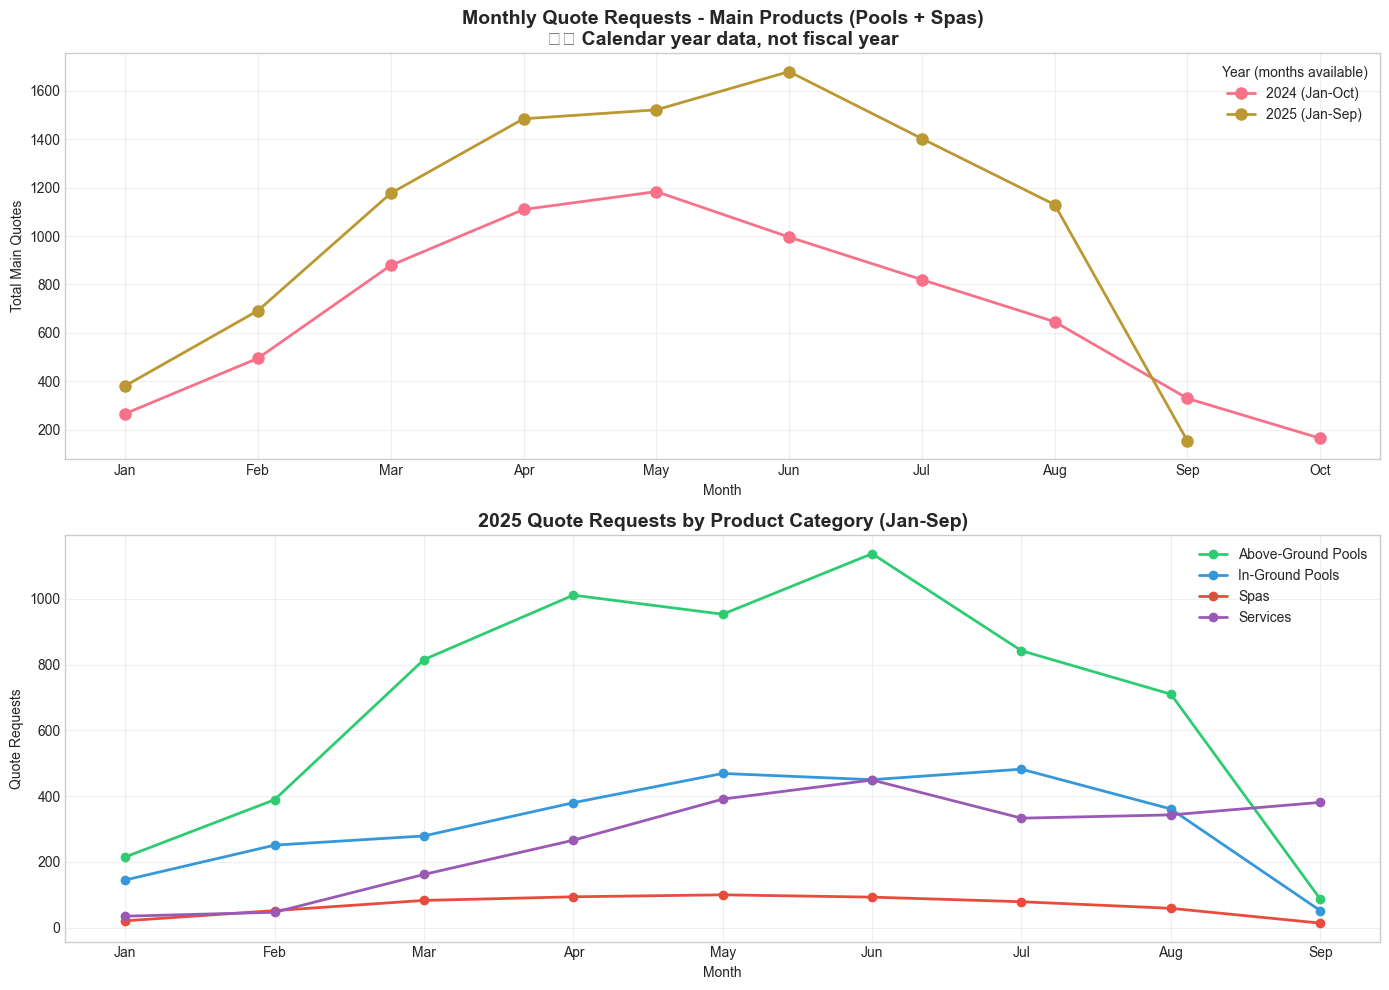


📈 Key Insights:
  - Peak season: April-July (spring/early summer)
  - Above-ground pools have highest volume and biggest seasonal swing
  - Services peak later (May-Sep) - likely follows pool purchases
  - 2025 consistently higher than 2024 across all months

💡 For MMM: Main Quotes (pools + spas) recommended as dependent variable
   Services may respond differently to marketing (lag effect from purchases)


In [4]:
# Cell 4: Quote Requests Time Series
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Total quotes over time (using filtered data)
ax1 = axes[0]
for year in [2024, 2025]:
    data = soumissions_clean[soumissions_clean['year'] == year]
    ax1.plot(data['month_num'], data['total_main_quotes'], 
             marker='o', linewidth=2, markersize=8, label=f'{year} (Jan-{"Oct" if year==2024 else "Sep"})')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Main Quotes')
ax1.set_title('Monthly Quote Requests - Main Products (Pools + Spas)\n⚠️ Calendar year data, not fiscal year', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(range(1, 11))  # Only show Jan-Oct since that's our data range
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct'])
ax1.legend(title='Year (months available)')
ax1.grid(True, alpha=0.3)

# Plot 2: Breakdown by product category (2025) - including services
ax2 = axes[1]
soumissions_2025 = soumissions_clean[soumissions_clean['year'] == 2025].copy()
categories = ['piscines_hors_terre', 'piscines_creusees', 'spas', 'services']
labels = ['Above-Ground Pools', 'In-Ground Pools', 'Spas', 'Services']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

for cat, label, color in zip(categories, labels, colors):
    ax2.plot(soumissions_2025['month_num'], soumissions_2025[cat], 
             marker='o', linewidth=2, label=label, color=color)

ax2.set_xlabel('Month')
ax2.set_ylabel('Quote Requests')
ax2.set_title('2025 Quote Requests by Product Category (Jan-Sep)', fontsize=14, fontweight='bold')
ax2.set_xticks(range(1, 10))  # Jan-Sep for 2025
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep'])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_path / 'quotes_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Key Insights:")
print("  - Peak season: April-July (spring/early summer)")
print("  - Above-ground pools have highest volume and biggest seasonal swing")
print("  - Services peak later (May-Sep) - likely follows pool purchases")
print("  - 2025 consistently higher than 2024 across all months")
print("\n💡 For MMM: Main Quotes (pools + spas) recommended as dependent variable")
print("   Services may respond differently to marketing (lag effect from purchases)")

---
## 2. Media Spend Analysis (Budget)

Understanding the marketing investments across different channels.

In [5]:
# Cell 5: Media Spend Overview - 2024 vs 2025 Comparison
print("=" * 80)
print("MEDIA SPEND COMPARISON: FISCAL 2024 vs FISCAL 2025")
print("=" * 80)
print("""
📅 Fiscal Year Definition:
   - Fiscal 2024 = November 2023 → October 2024
   - Fiscal 2025 = November 2024 → October 2025

⚠️  Note: Budget data is organized by fiscal year (Nov-Oct).
   The 'year' column in budget data refers to the FISCAL year.
""")

# Normalize channel names (handle naming inconsistencies between years)
budget_normalized = budget.copy()
channel_mapping = {
    'CIRCULAIRE DIGITAL': 'CIRCULAIRE DIGITALE',  # Normalize spelling
    'PANNEAUX': 'PANNEAUX / AFFICHAGE',            # Combine outdoor/billboard
    'PANNEAUX ET AFFICHAGES NUMÉRIQUES': 'PANNEAUX / AFFICHAGE'
}
budget_normalized['media_channel'] = budget_normalized['media_channel'].replace(channel_mapping)

# Define channel categories (groups from data cleaning logic)
channel_groups = {
    'TELEVISION': 'Traditional Media',
    'RADIO': 'Traditional Media',
    'RADIO NUMÉRIQUE': 'Traditional Media',
    'GOOGLE ADS': 'Digital Performance',
    'GOOGLE SHOPPING': 'Digital Performance',
    'SOCIAL MEDIA': 'Digital Performance',
    'BANNIÈRES WEB - PREMIUM': 'Digital Display',
    'PREROLL - PREMIUM': 'Digital Display',
    'CIRCULAIRE DIGITALE': 'Digital Display',
    'LAPRESSE (LP+, PREROLL, DISPLAY)': 'Digital Display',
    'PANNEAUX / AFFICHAGE': 'Out-of-Home',
    'CONTENU DE MARQUE': 'Content Marketing'
}
budget_normalized['channel_group'] = budget_normalized['media_channel'].map(channel_groups).fillna('Other')

# ============================================================
# DETAILED CHANNEL COMPARISON (2024 vs 2025)
# ============================================================
print("\n" + "=" * 80)
print("MEDIA SPEND BY CHANNEL - FISCAL YEAR COMPARISON")
print("=" * 80)

# Pivot by channel and year
channel_comparison = budget_normalized.pivot_table(
    index='media_channel', 
    columns='year', 
    values='spend', 
    aggfunc='sum', 
    fill_value=0
)

# Calculate totals for percentage
total_2024 = channel_comparison[2024].sum() if 2024 in channel_comparison.columns else 0
total_2025 = channel_comparison[2025].sum() if 2025 in channel_comparison.columns else 0

# Add calculated columns
channel_comparison['Difference'] = channel_comparison.get(2025, 0) - channel_comparison.get(2024, 0)
channel_comparison['% of FY24'] = (channel_comparison.get(2024, 0) / total_2024 * 100) if total_2024 > 0 else 0
channel_comparison['% of FY25'] = (channel_comparison.get(2025, 0) / total_2025 * 100) if total_2025 > 0 else 0
channel_comparison['% Change'] = ((channel_comparison.get(2025, 0) / channel_comparison.get(2024, 0).replace(0, np.nan)) - 1) * 100

# Sort by 2025 spend
channel_comparison = channel_comparison.sort_values(2025, ascending=False)

print(f"\n{'Channel':<40} {'FY 2024':>12} {'% Total':>8} {'FY 2025':>12} {'% Total':>8} {'Diff':>12} {'% Chg':>8}")
print("-" * 100)

for channel in channel_comparison.index:
    row = channel_comparison.loc[channel]
    spend_2024 = row.get(2024, 0)
    spend_2025 = row.get(2025, 0)
    diff = row['Difference']
    pct_2024 = row['% of FY24']
    pct_2025 = row['% of FY25']
    pct_chg = row['% Change']
    
    if pd.isna(pct_chg):
        pct_chg_str = "NEW" if spend_2025 > 0 else "-"
    elif spend_2024 == 0:
        pct_chg_str = "NEW"
    elif spend_2025 == 0:
        pct_chg_str = "DISC"  # Discontinued
    else:
        pct_chg_str = f"{pct_chg:+.0f}%"
    
    print(f"{channel:<40} ${spend_2024:>10,.0f} {pct_2024:>7.1f}% ${spend_2025:>10,.0f} {pct_2025:>7.1f}% ${diff:>+10,.0f} {pct_chg_str:>8}")

print("-" * 100)
print(f"{'TOTAL':<40} ${total_2024:>10,.0f} {100:>7.1f}% ${total_2025:>10,.0f} {100:>7.1f}% ${total_2025-total_2024:>+10,.0f} {((total_2025/total_2024)-1)*100:>+7.1f}%")

# ============================================================
# SUMMARY BY CHANNEL GROUP
# ============================================================
print("\n" + "=" * 80)
print("MEDIA SPEND BY CHANNEL GROUP")
print("=" * 80)

group_comparison = budget_normalized.pivot_table(
    index='channel_group', 
    columns='year', 
    values='spend', 
    aggfunc='sum', 
    fill_value=0
)
group_comparison['Difference'] = group_comparison.get(2025, 0) - group_comparison.get(2024, 0)
group_comparison['% of FY24'] = (group_comparison.get(2024, 0) / total_2024 * 100) if total_2024 > 0 else 0
group_comparison['% of FY25'] = (group_comparison.get(2025, 0) / total_2025 * 100) if total_2025 > 0 else 0
group_comparison = group_comparison.sort_values(2025, ascending=False)

print(f"\n{'Channel Group':<25} {'FY 2024':>12} {'% Total':>8} {'FY 2025':>12} {'% Total':>8} {'Diff':>12}")
print("-" * 80)
for group in group_comparison.index:
    row = group_comparison.loc[group]
    print(f"{group:<25} ${row.get(2024, 0):>10,.0f} {row['% of FY24']:>7.1f}% ${row.get(2025, 0):>10,.0f} {row['% of FY25']:>7.1f}% ${row['Difference']:>+10,.0f}")

print("\n💡 Key Observations:")
print("   - Traditional Media (TV + Radio) remains the largest spend category")
print("   - Digital Display channels gained budget share in FY25")
print("   - Some channels were consolidated/renamed between years")

MEDIA SPEND COMPARISON: FISCAL 2024 vs FISCAL 2025

📅 Fiscal Year Definition:
   - Fiscal 2024 = November 2023 → October 2024
   - Fiscal 2025 = November 2024 → October 2025

⚠️  Note: Budget data is organized by fiscal year (Nov-Oct).
   The 'year' column in budget data refers to the FISCAL year.


MEDIA SPEND BY CHANNEL - FISCAL YEAR COMPARISON

Channel                                       FY 2024  % Total      FY 2025  % Total         Diff    % Chg
----------------------------------------------------------------------------------------------------
TELEVISION                               $ 1,047,568    37.0% $   870,000    30.2% $  -177,568     -17%
RADIO                                    $   662,606    23.4% $   738,863    25.7% $   +76,257     +12%
PREROLL - PREMIUM                        $    96,486     3.4% $   240,000     8.3% $  +143,514    +149%
GOOGLE ADS                               $   430,973    15.2% $   235,709     8.2% $  -195,264     -45%
SOCIAL MEDIA              

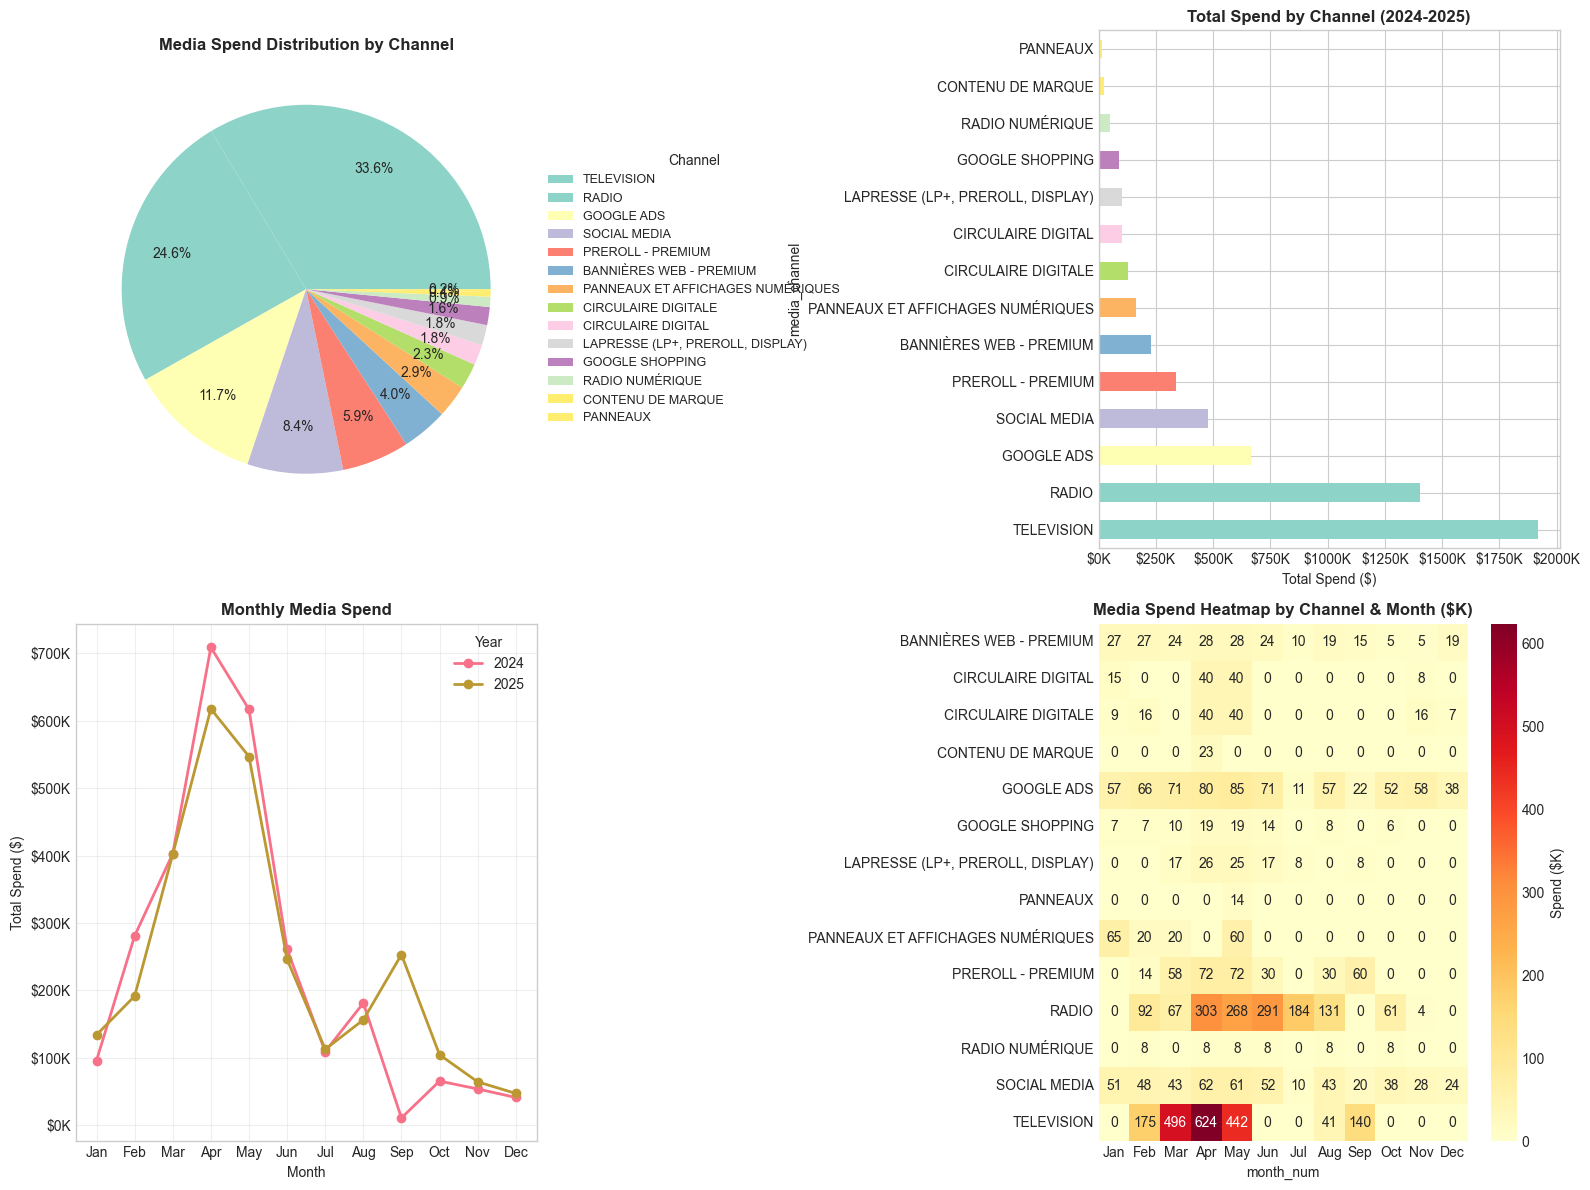


📈 Key Insights:
  - TV and Radio are the largest spend channels
  - Media spend increases March-June, aligning with peak quote season
  - Digital channels (Google, Social) have more consistent year-round presence


In [6]:
# Cell 6: Media Spend Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Spend by channel (pie chart)
ax1 = axes[0, 0]
channel_spend = budget.groupby('media_channel')['spend'].sum().sort_values(ascending=False)
colors = plt.cm.Set3(np.linspace(0, 1, len(channel_spend)))
wedges, texts, autotexts = ax1.pie(channel_spend, labels=None, autopct='%1.1f%%', 
                                    colors=colors, pctdistance=0.75)
ax1.legend(wedges, channel_spend.index, title="Channel", loc="center left", 
           bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)
ax1.set_title('Media Spend Distribution by Channel', fontsize=12, fontweight='bold')

# Plot 2: Spend by channel (bar chart)
ax2 = axes[0, 1]
channel_spend.plot(kind='barh', ax=ax2, color=colors)
ax2.set_xlabel('Total Spend ($)')
ax2.set_title('Total Spend by Channel (2024-2025)', fontsize=12, fontweight='bold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Plot 3: Monthly spend over time (2024 vs 2025)
ax3 = axes[1, 0]
monthly_spend = budget.groupby(['year', 'month_num'])['spend'].sum().unstack(level=0)
month_order = [11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # Fiscal year order
for year in [2024, 2025]:
    if year in monthly_spend.columns:
        data = monthly_spend[year].reindex(range(1, 13))
        ax3.plot(range(1, 13), data.values, marker='o', linewidth=2, label=str(year))
ax3.set_xlabel('Month')
ax3.set_ylabel('Total Spend ($)')
ax3.set_title('Monthly Media Spend', fontsize=12, fontweight='bold')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax3.legend(title='Year')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax3.grid(True, alpha=0.3)

# Plot 4: Spend by channel over months (heatmap)
ax4 = axes[1, 1]
pivot = budget.pivot_table(index='media_channel', columns='month_num', 
                           values='spend', aggfunc='sum', fill_value=0)
pivot = pivot.reindex(columns=range(1, 13))
sns.heatmap(pivot/1000, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax4, 
            cbar_kws={'label': 'Spend ($K)'})
ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax4.set_title('Media Spend Heatmap by Channel & Month ($K)', fontsize=12, fontweight='bold')
ax4.set_ylabel('')

plt.tight_layout()
plt.savefig(figures_path / 'media_spend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Key Insights:")
print("  - TV and Radio are the largest spend channels")
print("  - Media spend increases March-June, aligning with peak quote season")
print("  - Digital channels (Google, Social) have more consistent year-round presence")

---
## 3. Quotes vs Media Spend Correlation

Analyzing the relationship between marketing investments and quote requests.

In [7]:
# Cell 7: Prepare Merged Dataset for Correlation Analysis

# Pivot budget to wide format (one column per channel)
budget_wide = budget.pivot_table(
    index=['year', 'month_num'], 
    columns='media_channel', 
    values='spend', 
    aggfunc='sum', 
    fill_value=0
).reset_index()

# Flatten column names
budget_wide.columns = ['year', 'month_num'] + [f'spend_{col.lower().replace(" ", "_").replace("-", "_")}' 
                                                for col in budget_wide.columns[2:]]

# Add total spend column
spend_cols = [col for col in budget_wide.columns if col.startswith('spend_')]
budget_wide['spend_total'] = budget_wide[spend_cols].sum(axis=1)

# Merge with soumissions (using cleaned data with valid months only)
merged = soumissions_clean.merge(budget_wide, on=['year', 'month_num'], how='inner')

print(f"Merged dataset shape: {merged.shape}")
print(f"Months with both quotes and spend data: {len(merged)}")
print(f"Note: Using filtered soumissions data (excluding Nov/Dec with no data)")
print(f"\nColumns available: {merged.columns.tolist()}")

Merged dataset shape: (19, 27)
Months with both quotes and spend data: 19
Note: Using filtered soumissions data (excluding Nov/Dec with no data)

Columns available: ['year', 'month', 'month_num', 'piscines_hors_terre', 'piscines_creusees', 'spas', 'autres_produits', 'services', 'autre', 'total_main_quotes', 'total_all_quotes', 'date', 'spend_bannières_web___premium', 'spend_circulaire_digital', 'spend_circulaire_digitale', 'spend_contenu_de_marque', 'spend_google_ads', 'spend_google_shopping', 'spend_lapresse_(lp+,_preroll,_display)', 'spend_panneaux', 'spend_panneaux_et_affichages_numériques', 'spend_preroll___premium', 'spend_radio', 'spend_radio_numérique', 'spend_social_media', 'spend_television', 'spend_total']


CORRELATION WITH TOTAL MAIN QUOTES
  Radio                                    r = +0.782
  Lapresse (Lp+, Preroll, Display)         r = +0.631
  Total                                    r = +0.565
  Radio Numérique                          r = +0.549
  Circulaire Digitale                      r = +0.389
  Preroll   Premium                        r = +0.384
  Television                               r = +0.336
  Contenu De Marque                        r = +0.308
  Bannières Web   Premium                  r = +0.187
  Panneaux                                 r = +0.158
  Circulaire Digital                       r = +0.120
  Social Media                             r = +0.081
  Panneaux Et Affichages Numériques        r = +0.058
  Google Ads                               r = +0.011
  Google Shopping                          r = -0.001


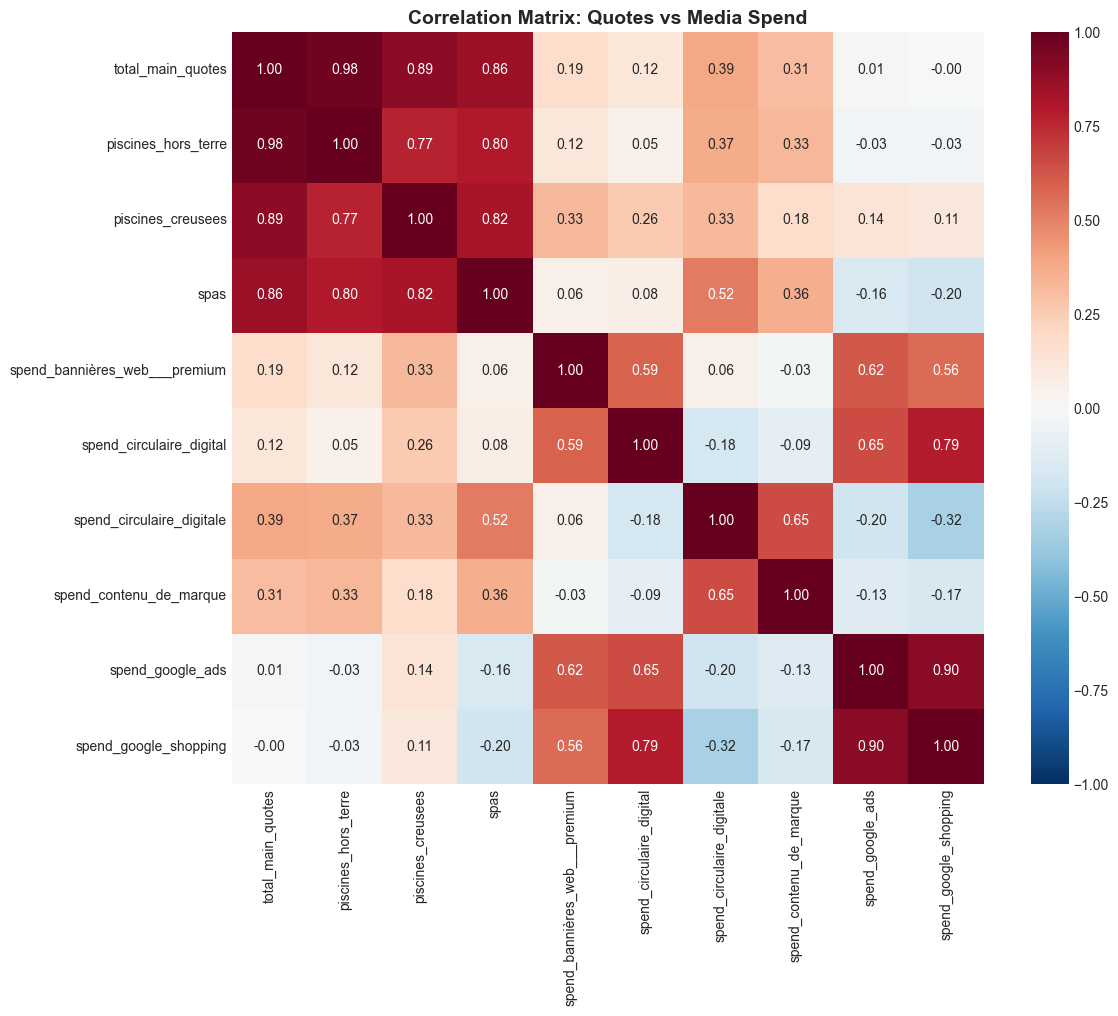

In [8]:
# Cell 8: Correlation Analysis

# Select relevant columns for correlation
quote_cols = ['total_main_quotes', 'piscines_hors_terre', 'piscines_creusees', 'spas']
spend_cols = [col for col in merged.columns if col.startswith('spend_')]

# Calculate correlations
corr_data = merged[quote_cols + spend_cols].corr()

# Extract correlations with total_main_quotes
print("=" * 60)
print("CORRELATION WITH TOTAL MAIN QUOTES")
print("=" * 60)
quotes_corr = corr_data['total_main_quotes'][spend_cols].sort_values(ascending=False)
for channel, corr in quotes_corr.items():
    channel_name = channel.replace('spend_', '').replace('_', ' ').title()
    print(f"  {channel_name:40} r = {corr:+.3f}")

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_data[quote_cols + spend_cols[:6]], dtype=bool))
corr_subset = corr_data.loc[quote_cols + spend_cols[:6], quote_cols + spend_cols[:6]]
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix: Quotes vs Media Spend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_path / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

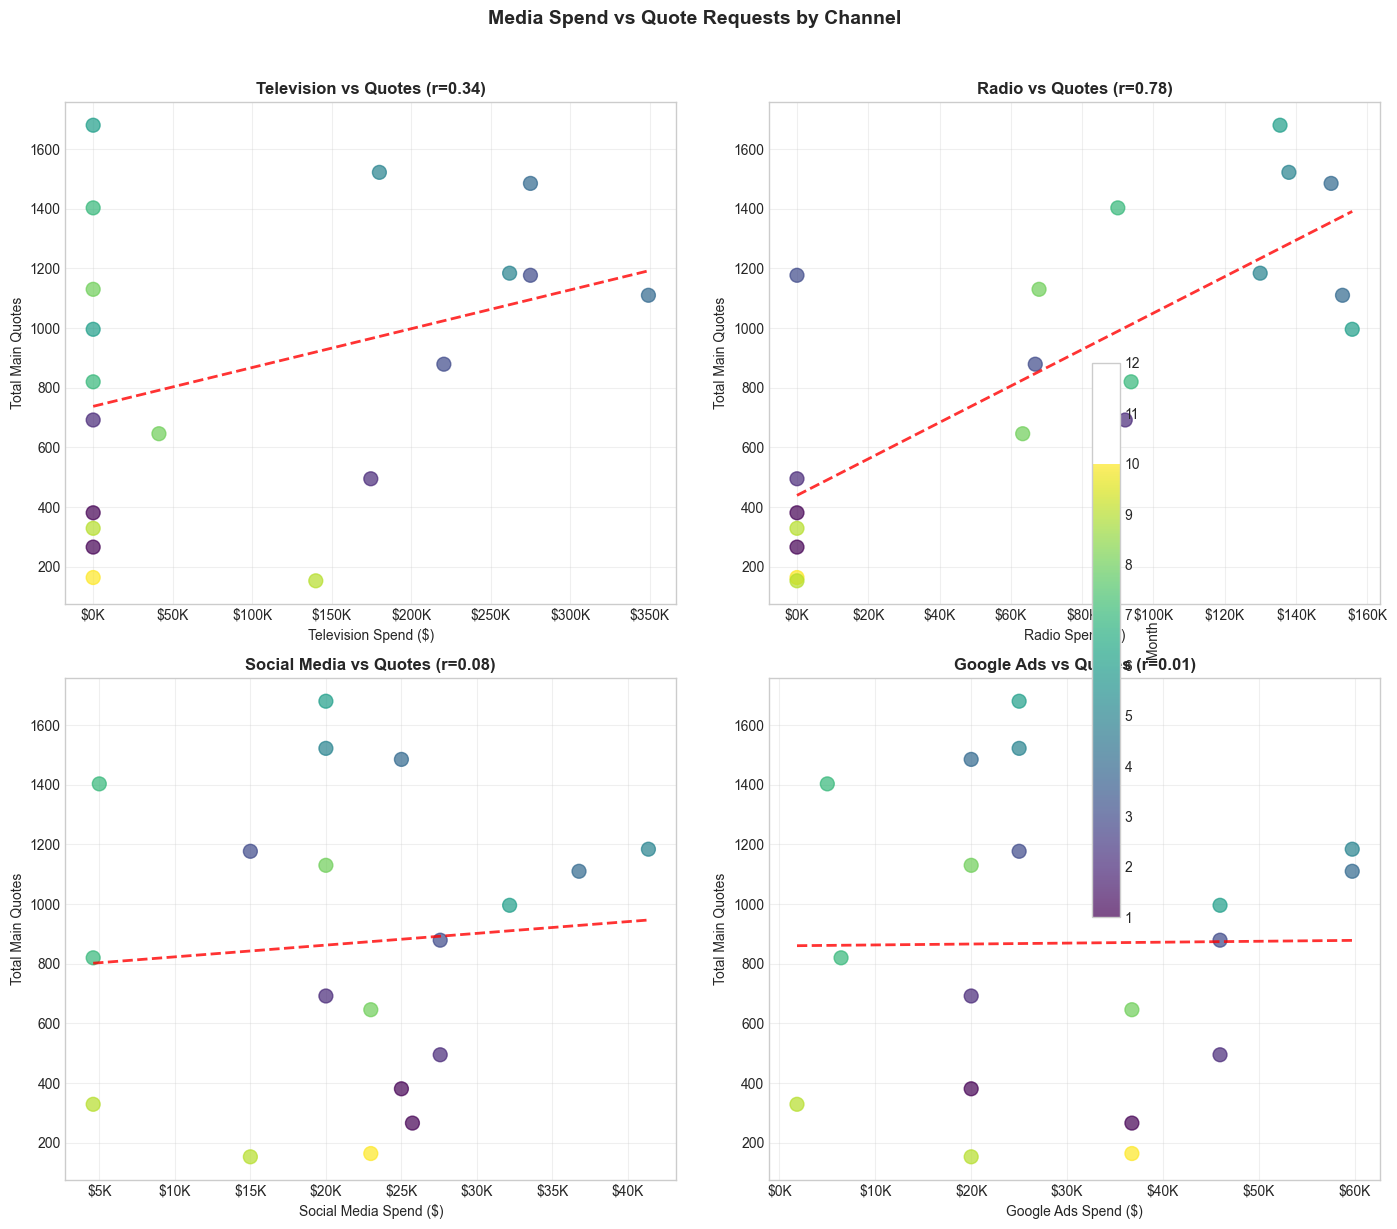


📈 Note: High correlations may be driven by seasonality (both spend and quotes increase in spring)
   The MMM model will help disentangle the true causal effect from seasonality.


In [9]:
# Cell 9: Scatter Plots - Spend vs Quotes

# Top 4 channels by spend
top_channels = ['spend_television', 'spend_radio', 'spend_social_media', 'spend_google_ads']
available_channels = [c for c in top_channels if c in merged.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, channel in enumerate(available_channels[:4]):
    ax = axes[i]
    channel_name = channel.replace('spend_', '').replace('_', ' ').title()
    
    # Scatter plot
    scatter = ax.scatter(merged[channel], merged['total_main_quotes'], 
                        c=merged['month_num'], cmap='viridis', s=100, alpha=0.7)
    
    # Add trend line
    if merged[channel].sum() > 0:
        z = np.polyfit(merged[channel], merged['total_main_quotes'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(merged[channel].min(), merged[channel].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    # Calculate correlation
    corr = merged[channel].corr(merged['total_main_quotes'])
    
    ax.set_xlabel(f'{channel_name} Spend ($)')
    ax.set_ylabel('Total Main Quotes')
    ax.set_title(f'{channel_name} vs Quotes (r={corr:.2f})', fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    ax.grid(True, alpha=0.3)

# Add colorbar for months
cbar = fig.colorbar(scatter, ax=axes, label='Month', shrink=0.6)
cbar.set_ticks(range(1, 13))

plt.suptitle('Media Spend vs Quote Requests by Channel', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'spend_vs_quotes_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Note: High correlations may be driven by seasonality (both spend and quotes increase in spring)")
print("   The MMM model will help disentangle the true causal effect from seasonality.")

---
## 4. Seasonality Analysis

Understanding the seasonal patterns critical for the MMM model.

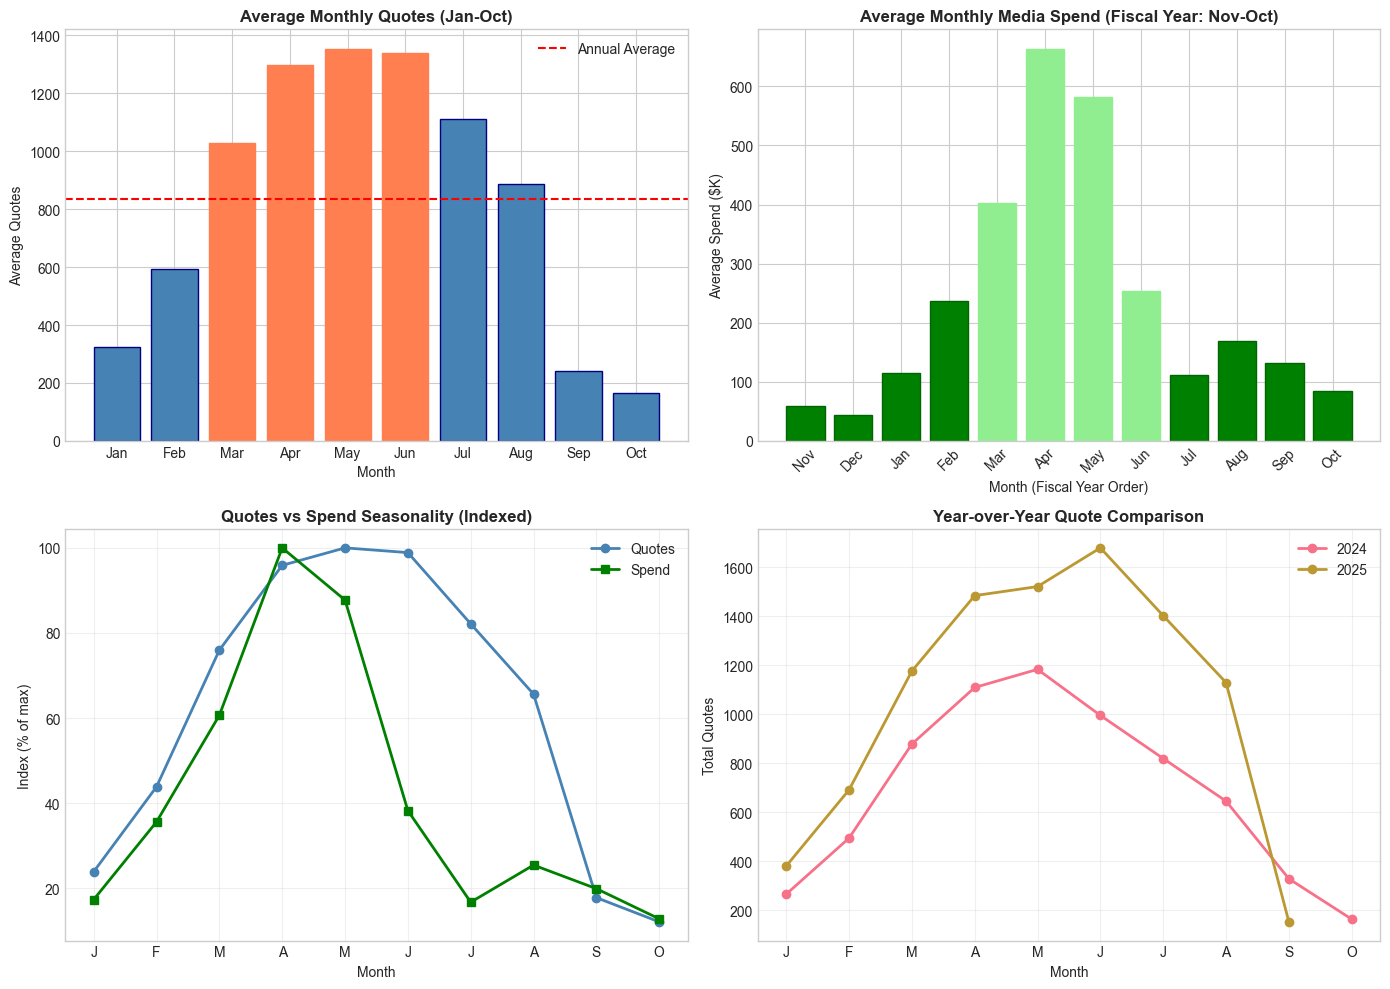


Key Seasonality Insights:
FISCAL YEAR: FY2024 = Nov 2023 - Oct 2024 | FY2025 = Nov 2024 - Oct 2025
- Peak season: March-June (spring/early summer)
- Low season: September-February (fall/winter)
- Media spend follows similar seasonal pattern
- 2025 shows higher quotes than 2024 (YoY growth)


In [10]:
# Cell 10: Seasonality Analysis

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Average quotes by month
ax1 = axes[0, 0]
monthly_avg_quotes = soumissions_clean.groupby('month_num')['total_main_quotes'].mean()
bars = ax1.bar(range(1, 11), monthly_avg_quotes.reindex(range(1, 11)).fillna(0), 
               color='steelblue', edgecolor='navy')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Quotes')
ax1.set_title('Average Monthly Quotes (Jan-Oct)', fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct'])
for i in [3, 4, 5, 6]:
    if i-1 < len(bars):
        bars[i-1].set_color('coral')
ax1.axhline(y=monthly_avg_quotes.mean(), color='red', linestyle='--', label='Annual Average')
ax1.legend()

# Plot 2: Average spend by month (fiscal year order: Nov-Oct)
ax2 = axes[0, 1]
monthly_avg_spend = budget.groupby('month_num')['spend'].sum() / 2
fiscal_month_order = [11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
fiscal_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']
fiscal_spend = [monthly_avg_spend.get(m, 0)/1000 for m in fiscal_month_order]
bars2 = ax2.bar(range(12), fiscal_spend, color='green', edgecolor='darkgreen')
ax2.set_xlabel('Month (Fiscal Year Order)')
ax2.set_ylabel('Average Spend ($K)')
ax2.set_title('Average Monthly Media Spend (Fiscal Year: Nov-Oct)', fontsize=12, fontweight='bold')
ax2.set_xticks(range(12))
ax2.set_xticklabels(fiscal_labels, rotation=45)
for i in [4, 5, 6, 7]:
    bars2[i].set_color('lightgreen')

# Plot 3: Quotes vs Spend overlay
ax3 = axes[1, 0]
quotes_idx = monthly_avg_quotes / monthly_avg_quotes.max() * 100
spend_idx = monthly_avg_spend / monthly_avg_spend.max() * 100
months_range = range(1, 11)
ax3.plot(months_range, [quotes_idx.get(m, 0) for m in months_range], 
         marker='o', linewidth=2, label='Quotes', color='steelblue')
ax3.plot(months_range, [spend_idx.get(m, 0) for m in months_range], 
         marker='s', linewidth=2, label='Spend', color='green')
ax3.set_xlabel('Month')
ax3.set_ylabel('Index (% of max)')
ax3.set_title('Quotes vs Spend Seasonality (Indexed)', fontsize=12, fontweight='bold')
ax3.set_xticks(months_range)
ax3.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O'])
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Year-over-Year comparison
ax4 = axes[1, 1]
for year in [2024, 2025]:
    data = soumissions_clean[soumissions_clean['year'] == year]
    ax4.plot(data['month_num'], data['total_main_quotes'], marker='o', linewidth=2, label=f'{year}')
ax4.set_xlabel('Month')
ax4.set_ylabel('Total Quotes')
ax4.set_title('Year-over-Year Quote Comparison', fontsize=12, fontweight='bold')
ax4.set_xticks(range(1, 11))
ax4.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O'])
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_path / 'seasonality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Seasonality Insights:")
print("=" * 70)
print("FISCAL YEAR: FY2024 = Nov 2023 - Oct 2024 | FY2025 = Nov 2024 - Oct 2025")
print("- Peak season: March-June (spring/early summer)")
print("- Low season: September-February (fall/winter)")
print("- Media spend follows similar seasonal pattern")
print("- 2025 shows higher quotes than 2024 (YoY growth)")

---
## 5. Media Type Performance Analysis (Tableau Medias)

Understanding performance metrics by media type (Numérique, Affichage, Radio, Télévision).

**Note:** Clicks/CTR metrics only apply to digital media (Numérique). TV, Radio, and Billboard (Affichage) don't have click tracking.

In [11]:
# Cell 11: Media Type Performance Overview

print("=" * 60)
print("MEDIA TYPE PERFORMANCE SUMMARY")
print("=" * 60)

# Summary by media type
media_summary = tableau_medias.groupby('media_type').agg({
    'cost_net': ['sum', 'mean', 'count'],
    'impressions_reel': 'sum',
    'clics_reel': 'sum'
}).round(2)

media_summary.columns = ['Total Cost', 'Avg Cost', 'Campaigns', 'Total Impressions', 'Total Clicks']
media_summary['CPM'] = (media_summary['Total Cost'] / media_summary['Total Impressions'] * 1000).round(2)

print("\nPerformance by Media Type (All Channels):")
print("-" * 80)
print(f"{'Media Type':<15} {'Total Cost':>15} {'Campaigns':>10} {'Impressions':>18} {'CPM':>10}")
print("-" * 80)

for media_type in media_summary.index:
    row = media_summary.loc[media_type]
    print(f"{media_type:<15} ${row['Total Cost']:>14,.0f} {int(row['Campaigns']):>10} {row['Total Impressions']:>18,.0f} ${row['CPM']:>9.2f}")

# Digital-only metrics (clicks/CTR only apply to digital)
print("\n" + "=" * 60)
print("DIGITAL MEDIA (NUMÉRIQUE) - CLICK METRICS")
print("=" * 60)
print("⚠️  Note: Clicks/CTR only applicable to digital channels")

digital_data = tableau_medias[tableau_medias['media_type'] == 'Numérique']
if not digital_data.empty:
    total_clicks = digital_data['clics_reel'].sum()
    total_impressions = digital_data['impressions_reel'].sum()
    ctr = (total_clicks / total_impressions * 100) if total_impressions > 0 else 0
    total_cost = digital_data['cost_net'].sum()
    cpc = (total_cost / total_clicks) if total_clicks > 0 else 0
    
    print(f"\nTotal Digital Impressions: {total_impressions:,.0f}")
    print(f"Total Clicks:              {total_clicks:,.0f}")
    print(f"Click-Through Rate (CTR):  {ctr:.3f}%")
    print(f"Cost per Click (CPC):      ${cpc:.2f}")

MEDIA TYPE PERFORMANCE SUMMARY

Performance by Media Type (All Channels):
--------------------------------------------------------------------------------
Media Type           Total Cost  Campaigns        Impressions        CPM
--------------------------------------------------------------------------------
Affichage       $       181,491         14        236,384,489 $     0.77
Numérique       $     1,195,626        101        111,860,821 $    10.69
Radio           $       799,103        215         57,016,900 $    14.02
Télévision      $     1,042,994         53         82,131,818 $    12.70

DIGITAL MEDIA (NUMÉRIQUE) - CLICK METRICS
⚠️  Note: Clicks/CTR only applicable to digital channels

Total Digital Impressions: 111,860,821
Total Clicks:              760,954
Click-Through Rate (CTR):  0.680%
Cost per Click (CPC):      $1.57


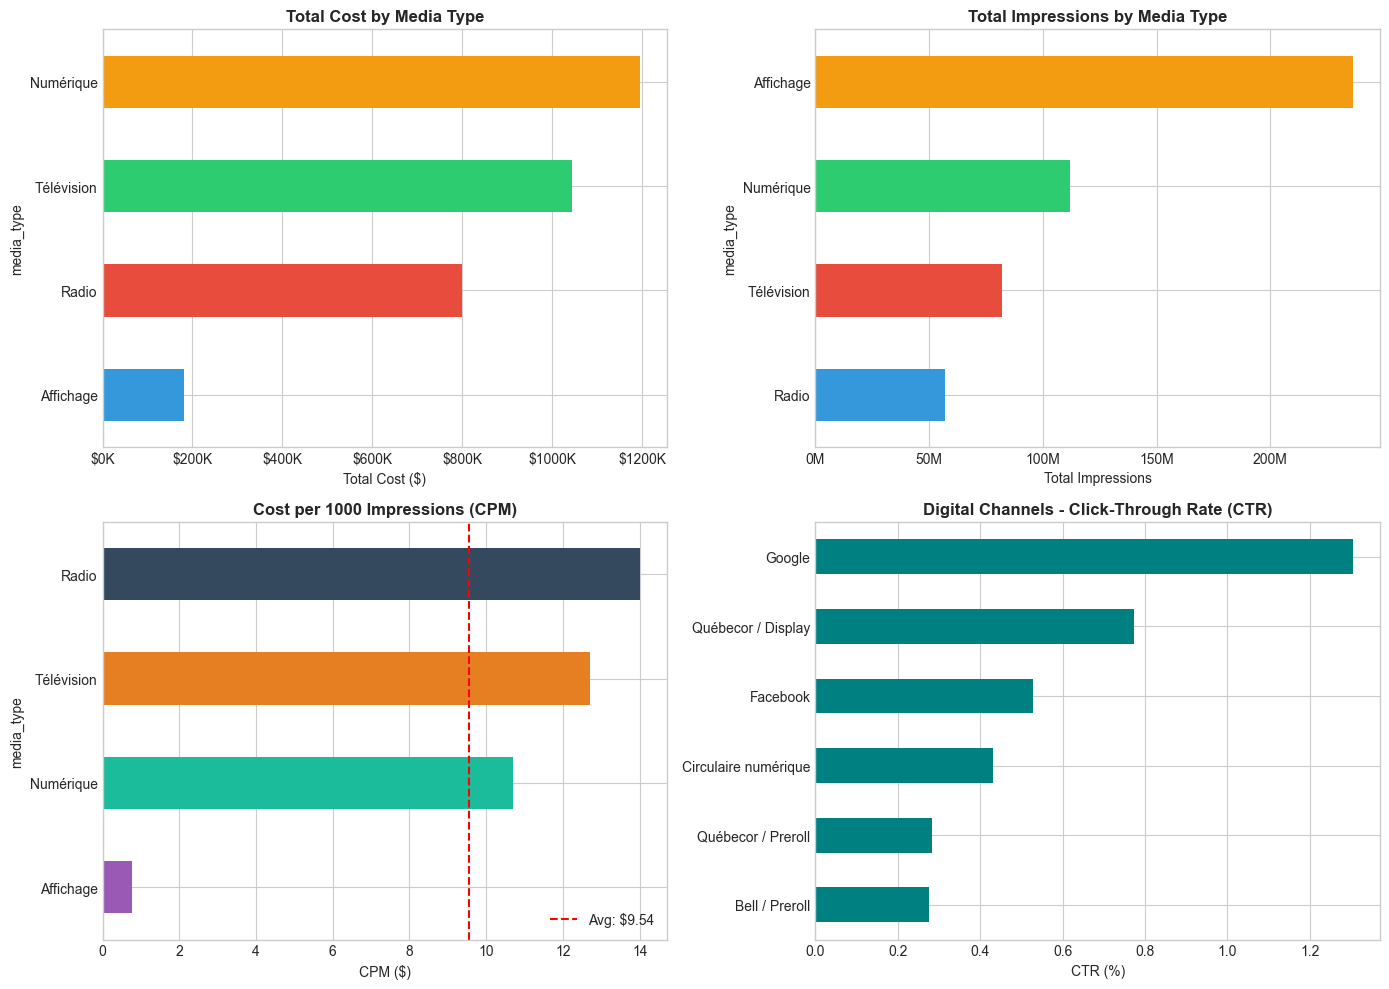


📈 Key Media Type Insights:
  - Digital (Numérique) has the lowest CPM and generates trackable clicks
  - TV has highest total spend and strong reach
  - Affichage (Billboard) has very high impressions at low CPM
  - Clicks/CTR only apply to digital media - TV/Radio/Billboard don't have click tracking


In [12]:
# Cell 12: Media Type Performance Visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cost by media type
ax1 = axes[0, 0]
media_cost = tableau_medias.groupby('media_type')['cost_net'].sum().sort_values(ascending=True)
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
media_cost.plot(kind='barh', ax=ax1, color=colors)
ax1.set_xlabel('Total Cost ($)')
ax1.set_title('Total Cost by Media Type', fontsize=12, fontweight='bold')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Plot 2: Impressions by media type
ax2 = axes[0, 1]
media_impr = tableau_medias.groupby('media_type')['impressions_reel'].sum().sort_values(ascending=True)
media_impr.plot(kind='barh', ax=ax2, color=colors)
ax2.set_xlabel('Total Impressions')
ax2.set_title('Total Impressions by Media Type', fontsize=12, fontweight='bold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

# Plot 3: CPM comparison
ax3 = axes[1, 0]
cpm_by_type = (tableau_medias.groupby('media_type')['cost_net'].sum() / 
               tableau_medias.groupby('media_type')['impressions_reel'].sum() * 1000)
cpm_by_type = cpm_by_type.sort_values(ascending=True)
cpm_by_type.plot(kind='barh', ax=ax3, color=['#9b59b6', '#1abc9c', '#e67e22', '#34495e'])
ax3.set_xlabel('CPM ($)')
ax3.set_title('Cost per 1000 Impressions (CPM)', fontsize=12, fontweight='bold')
ax3.axvline(x=cpm_by_type.mean(), color='red', linestyle='--', label=f'Avg: ${cpm_by_type.mean():.2f}')
ax3.legend()

# Plot 4: Digital-only click analysis (CTR by digital channel/support)
ax4 = axes[1, 1]
digital_channels = tableau_medias[tableau_medias['media_type'] == 'Numérique'].groupby('support').agg({
    'impressions_reel': 'sum',
    'clics_reel': 'sum',
    'cost_net': 'sum'
})
digital_channels['CTR'] = (digital_channels['clics_reel'] / digital_channels['impressions_reel'] * 100).fillna(0)
digital_channels = digital_channels.sort_values('cost_net', ascending=False).head(6)

if not digital_channels.empty:
    digital_channels['CTR'].sort_values(ascending=True).plot(kind='barh', ax=ax4, color='teal')
    ax4.set_xlabel('CTR (%)')
    ax4.set_title('Digital Channels - Click-Through Rate (CTR)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('')
else:
    ax4.text(0.5, 0.5, 'No digital channel data', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Digital Channels - CTR', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_path / 'campaign_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Key Media Type Insights:")
print("  - Digital (Numérique) has the lowest CPM and generates trackable clicks")
print("  - TV has highest total spend and strong reach")
print("  - Affichage (Billboard) has very high impressions at low CPM")
print("  - Clicks/CTR only apply to digital media - TV/Radio/Billboard don't have click tracking")

---
## 6. Summary & Insights for MMM

Key findings to inform the Media Mix Model development.

In [13]:
# Cell 13: EDA Summary

print("="*70)
print("EXPLORATORY DATA ANALYSIS - KEY FINDINGS")
print("="*70)

print("""
📊 DATA OVERVIEW:
─────────────────────────────────────────────────────────────────────
• Fiscal year: November to October (Fiscal 2024 = Nov 2023 - Oct 2024)
• Data available: January to October of 2024 and 2025
• Dependent variable: Quote requests (proxy for sales demand)
• Marketing channels: 9-11 channels including TV, Radio, Digital, Social
• Granularity: Monthly data

📈 SEASONALITY FINDINGS:
─────────────────────────────────────────────────────────────────────
• Strong seasonal pattern in pool/spa business
• Peak season: March-June (spring/early summer)
• Low season: September-February (fall/winter)
• Marketing spend follows demand seasonality

📦 PRODUCT CATEGORIES:
─────────────────────────────────────────────────────────────────────
• Main Quotes = Pools (above-ground + in-ground) + Spas (core products)
• Total Quotes = Main + Services + Accessories + Other
• Above-ground pools are the highest volume product
• Strong YoY growth observed in 2025 vs 2024 (comparable periods)

💰 MEDIA SPEND INSIGHTS:
─────────────────────────────────────────────────────────────────────
• Total annual budget: ~$2.8-2.9M
• Top channels by spend: TV (~35%), Radio (~25%), Digital (~20%)
• Digital channels (Google, Social) more consistent year-round
• Traditional media (TV, Radio) concentrated in peak season

📱 MEDIA TYPE PERFORMANCE:
─────────────────────────────────────────────────────────────────────
• 4 media types: Numérique (Digital), Télévision, Radio, Affichage (Billboard)
• Clicks/CTR only applicable to Digital (Numérique) channels
• Digital has lowest CPM and trackable engagement
• Billboard (Affichage) has high reach at low CPM

🔗 CORRELATION INSIGHTS:
─────────────────────────────────────────────────────────────────────
• High correlations between spend and quotes (driven by seasonality)
• Need to control for seasonality in MMM to isolate true media effects
• Consider lagged effects (adstock) for TV and Radio

⚠️  DATA QUALITY NOTES:
─────────────────────────────────────────────────────────────────────
• Nov-Dec show 0/NaN values (fiscal year ends in October)
• October 2025 quotes are incomplete/zero
• Campaign data has some missing metrics (preserved as NaN)
• Only 2 years of data - limited for detecting long-term trends

🎯 RECOMMENDATIONS FOR MMM:
─────────────────────────────────────────────────────────────────────
1. Include strong seasonality controls (monthly dummies or Fourier terms)
2. Apply adstock transformations for carryover effects
3. Consider diminishing returns (saturation curves)
4. Add external factors: weather data (temperature affects pool demand)
5. Use weekly data if available for more granularity
6. Consider interaction between channels
""")

print("="*70)
print("NEXT STEPS: Create 04_external_data.ipynb to collect weather data")
print("="*70)

EXPLORATORY DATA ANALYSIS - KEY FINDINGS

📊 DATA OVERVIEW:
─────────────────────────────────────────────────────────────────────
• Fiscal year: November to October (Fiscal 2024 = Nov 2023 - Oct 2024)
• Data available: January to October of 2024 and 2025
• Dependent variable: Quote requests (proxy for sales demand)
• Marketing channels: 9-11 channels including TV, Radio, Digital, Social
• Granularity: Monthly data

📈 SEASONALITY FINDINGS:
─────────────────────────────────────────────────────────────────────
• Strong seasonal pattern in pool/spa business
• Peak season: March-June (spring/early summer)
• Low season: September-February (fall/winter)
• Marketing spend follows demand seasonality

📦 PRODUCT CATEGORIES:
─────────────────────────────────────────────────────────────────────
• Main Quotes = Pools (above-ground + in-ground) + Spas (core products)
• Total Quotes = Main + Services + Accessories + Other
• Above-ground pools are the highest volume product
• Strong YoY growth observed 

In [14]:
# Cell 14: Save merged dataset for modeling

# Save the merged quotes + spend dataset (filtered, with valid months only)
merged.to_csv(processed_path / 'quotes_spend_merged.csv', index=False)
merged.to_pickle(processed_path / 'quotes_spend_merged.pkl')

print(f"✓ Saved merged dataset: {processed_path / 'quotes_spend_merged.pkl'}")
print(f"  Shape: {merged.shape}")
print(f"  Note: Contains only months with valid quote data (Jan-Oct, excluding Nov/Dec)")
print(f"  Columns: {merged.columns.tolist()}")

✓ Saved merged dataset: /Users/tuta/Desktop/busa693-clubpiscine/data/processed/quotes_spend_merged.pkl
  Shape: (19, 27)
  Note: Contains only months with valid quote data (Jan-Oct, excluding Nov/Dec)
  Columns: ['year', 'month', 'month_num', 'piscines_hors_terre', 'piscines_creusees', 'spas', 'autres_produits', 'services', 'autre', 'total_main_quotes', 'total_all_quotes', 'date', 'spend_bannières_web___premium', 'spend_circulaire_digital', 'spend_circulaire_digitale', 'spend_contenu_de_marque', 'spend_google_ads', 'spend_google_shopping', 'spend_lapresse_(lp+,_preroll,_display)', 'spend_panneaux', 'spend_panneaux_et_affichages_numériques', 'spend_preroll___premium', 'spend_radio', 'spend_radio_numérique', 'spend_social_media', 'spend_television', 'spend_total']
